<a href="https://colab.research.google.com/github/HiveCase/Group-1-DS-and-AI-Lab-Project/blob/main/notebooks/EDA_VehiDE_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VehiDE Dataset — Exploratory Data Analysis
**Dataset:** VehiDE: Vehicle Damage Detection Dataset
**Source:** https://www.kaggle.com/datasets/hendrichscullen/vehide-dataset-automatic-vehicle-damage-detection


This notebook performs EDA on an **image + annotation** dataset.

| Tabular EDA concept | Image-dataset equivalent used here |
|---|---|
| Summary statistics | Image counts, resolution stats, instances-per-image stats |
| Feature distributions | Width / height / aspect ratio / file-size distributions |
| Class distribution | Damage-category instance counts |
| Missing values | Images without annotations, annotations without images, corrupt files |
| Duplicate analysis | Exact duplicate images (hash-based), duplicate annotation entries |
| Outlier analysis | Resolution outliers, bounding-box size outliers, instance-count outliers |
| Correlation analysis | Correlation between numeric image/annotation features |
| Visualizations | Histograms, bar charts, scatter plots, heatmaps, sample image grids |


## 1. Setup

In [1]:
import os, io, json, glob, hashlib, zipfile, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)

## 1.1 Dataset Download

In [2]:
!pip install -q kaggle


In [3]:
from google.colab import files

# Upload kaggle.json when prompted (skip this cell if already uploaded / mounted via Drive)
if not os.path.exists("/root/.kaggle/kaggle.json"):
    uploaded = files.upload()  # select kaggle.json
    os.makedirs("/root/.kaggle", exist_ok=True)
    for fname in uploaded:
        os.rename(fname, f"/root/.kaggle/{fname}")
    os.chmod("/root/.kaggle/kaggle.json", 0o600)

Saving kaggle.json to kaggle.json


In [4]:
DATASET_SLUG = "hendrichscullen/vehide-dataset-automatic-vehicle-damage-detection"
DOWNLOAD_DIR = "/content/vehide_raw"
DATA_ROOT = "/content/vehide"

os.makedirs(DOWNLOAD_DIR, exist_ok=True)
os.makedirs(DATA_ROOT, exist_ok=True)

if not os.listdir(DATA_ROOT):
    !kaggle datasets download -d {DATASET_SLUG} -p {DOWNLOAD_DIR} --unzip -q
    # Fallback: if --unzip didn't extract everything (large files), unzip manually
    for z in glob.glob(f"{DOWNLOAD_DIR}/*.zip"):
        with zipfile.ZipFile(z, "r") as zf:
            zf.extractall(DOWNLOAD_DIR)
    DATA_ROOT = DOWNLOAD_DIR

print("Dataset root:", DATA_ROOT)

Dataset URL: https://www.kaggle.com/datasets/hendrichscullen/vehide-dataset-automatic-vehicle-damage-detection
License(s): apache-2.0
Dataset root: /content/vehide_raw


## 2. Directory Structure Exploration

In [5]:
def walk_summary(root, max_depth=3):
    root = Path(root)
    rows = []
    for dirpath, dirnames, filenames in os.walk(root):
        depth = len(Path(dirpath).relative_to(root).parts)
        if depth > max_depth:
            dirnames[:] = []
            continue
        ext_counts = Counter(Path(f).suffix.lower() for f in filenames)
        rows.append({
            "path": str(Path(dirpath).relative_to(root)) or ".",
            "n_files": len(filenames),
            "n_subdirs": len(dirnames),
            "extensions": dict(ext_counts),
        })
    return pd.DataFrame(rows)

structure_df = walk_summary(DATA_ROOT)
structure_df

,path,n_files,n_subdirs,extensions
0,.,2,2,{'.json': 2}
1,validation,0,1,{}
2,validation/validation,2324,0,{'.jpg': 2324}
3,image,0,1,{}
4,image/image,11621,0,{'.jpg': 11621}


In [6]:
# File-extension totals across the whole dataset (flat count, any depth)
all_files = [Path(p) for p in glob.glob(f"{DATA_ROOT}/**/*", recursive=True) if os.path.isfile(p)]
ext_totals = Counter(f.suffix.lower() for f in all_files)

print(f"Total files on disk: {len(all_files):,}")
for ext, cnt in ext_totals.most_common():
    print(f"  {ext or '[no ext]':>8}: {cnt:,}")

total_size_gb = sum(f.stat().st_size for f in all_files) / (1024**3)
print(f"\nTotal dataset size: {total_size_gb:.2f} GB")

Total files on disk: 13,947
      .jpg: 13,945
     .json: 2

Total dataset size: 2.19 GB


## 3. Annotation Discovery & Loading

In [7]:
json_candidates = [p for p in glob.glob(f"{DATA_ROOT}/**/*.json", recursive=True)]
print(f"Found {len(json_candidates)} JSON file(s):")
for p in json_candidates:
    print(" -", p)

# Inspect the top-level keys of each candidate so we can confirm the schema
for p in json_candidates[:5]:
    try:
        with open(p) as f:
            sample = json.load(f)
        keys = list(sample.keys()) if isinstance(sample, dict) else f"list, len={len(sample)}"
        print(f"\n{p}\n  top-level keys: {keys}")
    except Exception as e:
        print(f"\n{p}\n  could not parse: {e}")

Found 2 JSON file(s):
 - /content/vehide_raw/0Val_via_annos.json
 - /content/vehide_raw/0Train_via_annos.json

/content/vehide_raw/0Val_via_annos.json
  top-level keys: ['01022020_104459image894113.jpg', '01022020_104510image892040.jpg', '01022020_153342image229797.jpg', '01042020_091351image21145.jpg', '01092020_102550image661127.jpg', '01102020_090107image683356.jpg', '01102020_094657image929398.jpg', '01102020_111044image686093.jpg', '01102020_135233image760694.jpg', '01102020_143836image693240.jpg', '01102020_144502image357880.jpg', '01102020_161817image463312.jpg', '01122020_111211image549999.jpg', '02012020_074827image500275.jpg', '02012020_081245image375877.jpg', '02012020_081348image702557.jpg', '02012020_081637image167248.jpg', '02012020_082149image965429.jpg', '02012020_082207image933812.jpg', '02012020_082351image2366.jpg', '02012020_082351image999793.jpg', '02012020_082354image536102.jpg', '02012020_083643image180641.jpg', '02012020_084053image872857.jpg', '02012020_084201i

In [8]:
# --- COCO-style parser -----------------------------------------------------
# Expects: {"images": [...], "annotations": [...], "categories": [...]}

def load_coco_jsons(paths):
    images, annotations, categories = [], [], []
    for p in paths:
        with open(p) as f:
            d = json.load(f)
        if not isinstance(d, dict) or "annotations" not in d:
            continue
        images.extend(d.get("images", []))
        annotations.extend(d.get("annotations", []))
        categories.extend(d.get("categories", []))
    return images, annotations, categories

In [9]:
# --- VIA-style parser --------------------------------------------------------
# VehiDE's actual schema (confirmed from data inspection):
# {
#   "<filename.jpg>": {
#     "regions": [
#       {"all_x": [...], "all_y": [...], "class": "rach"},
#       ...
#     ]
#   }, ...
# }
# The region dict has "all_x"/"all_y" (polygon points) and "class" directly —
# no nested "shape_attributes"/"region_attributes" wrappers.

def _via_polygon_bbox(all_x, all_y):
    """Return [x_min, y_min, width, height] bounding box from polygon vertices."""
    if not all_x or not all_y:
        return None
    x = min(all_x); y = min(all_y)
    w = max(all_x) - x; h = max(all_y) - y
    return [x, y, w, h]

In [10]:
def load_via_jsons(paths):
    images, annotations, categories = [], [], []
    cat_to_id, next_cat_id, next_ann_id, next_img_id = {}, 0, 0, 0

    for p in paths:
        with open(p) as f:
            d = json.load(f)

        # Optionally unwrap "_via_img_metadata" wrapper (older VIA exports)
        img_dict = d.get("_via_img_metadata", d) if isinstance(d, dict) else {}
        if not isinstance(img_dict, dict):
            continue

        for key, entry in img_dict.items():
            if not isinstance(entry, dict):
                continue

            # The top-level key IS the filename in VehiDE's format
            filename = entry.get("filename") or key
            regions = entry.get("regions", [])
            if not isinstance(regions, list):
                continue

            img_id = next_img_id; next_img_id += 1
            images.append({"id": img_id, "file_name": filename,
                            "width": None, "height": None})

            for region in regions:
                if not isinstance(region, dict):
                    continue

                # ── VehiDE flat schema: all_x / all_y / class ──────────────
                all_x = region.get("all_x")
                all_y = region.get("all_y")
                class_name = region.get("class", "unknown")

                # ── Fallback: old VIA nested schema ────────────────────────
                if all_x is None:
                    shape = region.get("shape_attributes", {})
                    all_x = shape.get("all_points_x")
                    all_y = shape.get("all_points_y")
                    if all_x is None and shape.get("name") == "rect":
                        x0 = shape["x"]; y0 = shape["y"]
                        w0 = shape["width"]; h0 = shape["height"]
                        all_x = [x0, x0 + w0]; all_y = [y0, y0 + h0]
                    attrs = region.get("region_attributes", {})
                    if attrs:
                        class_name = next(iter(attrs.values()), "unknown")

                bbox = _via_polygon_bbox(all_x, all_y)
                if bbox is None:
                    continue

                if class_name not in cat_to_id:
                    cat_to_id[class_name] = next_cat_id; next_cat_id += 1
                annotations.append({
                    "id": next_ann_id, "image_id": img_id,
                    "category_id": cat_to_id[class_name],
                    "bbox": bbox, "area": bbox[2] * bbox[3],
                })
                next_ann_id += 1

        categories = [{"id": i, "name": n} for n, i in cat_to_id.items()]

    return images, annotations, categories

In [11]:
images_raw, annotations_raw, categories_raw = load_coco_jsons(json_candidates)
parser_used = "COCO"

if not annotations_raw:
    images_raw, annotations_raw, categories_raw = load_via_jsons(json_candidates)
    parser_used = "VIA"

images_df = pd.DataFrame(images_raw).drop_duplicates(subset="id") if images_raw else pd.DataFrame()
annotations_df = pd.DataFrame(annotations_raw) if annotations_raw else pd.DataFrame()
categories_df = pd.DataFrame(categories_raw).drop_duplicates(subset="id") if categories_raw else pd.DataFrame()

print(f"Parser used: {parser_used}")
print("images_df:", images_df.shape)
print("annotations_df:", annotations_df.shape)
print("categories_df:", categories_df.shape)

if annotations_df.empty and json_candidates:
    print("\n⚠️  Still empty — inspecting raw structure of the first entry for debugging:")
    with open(json_candidates[0]) as f:
        _raw = json.load(f)
    _first_key = next(iter(_raw))
    print("First key:", _first_key)
    print("First entry:", json.dumps(_raw[_first_key], indent=2)[:1000])

images_df.head()

Parser used: VIA
images_df: (13945, 4)
annotations_df: (36081, 5)
categories_df: (7, 2)


,id,file_name,width,height
0,0,01022020_104459image894113.jpg,None,None
1,1,01022020_104510image892040.jpg,None,None
2,2,01022020_153342image229797.jpg,None,None
3,3,01042020_091351image21145.jpg,None,None
4,4,01092020_102550image661127.jpg,None,None


In [12]:
# No-op placeholder — only fill in if Section 2's auto-parser returned empty DataFrames.
if images_df.empty or annotations_df.empty:
    print("⚠️  Auto-parse returned empty DataFrame(s). Inspect the printed JSON keys above "
          "and adapt the loader before continuing.")
else:
    print("Auto-parsed annotation DataFrames look populated — no manual override needed.")


Auto-parsed annotation DataFrames look populated — no manual override needed.


In [13]:
# Map category_id -> class name onto the annotations table for convenience
if not categories_df.empty and not annotations_df.empty:
    cat_map = dict(zip(categories_df["id"], categories_df["name"]))
    annotations_df["category_name"] = annotations_df["category_id"].map(cat_map)

# Map file_name onto annotations for convenience
if not images_df.empty and not annotations_df.empty:
    file_map = dict(zip(images_df["id"], images_df["file_name"]))
    annotations_df["file_name"] = annotations_df["image_id"].map(file_map)

annotations_df.head()

,id,image_id,category_id,bbox,area,category_name,file_name
0,0,0,0,"[839, 565, 325, 219]",71175,rach,01022020_104459image894113.jpg
1,1,0,0,"[59, 577, 296, 165]",48840,rach,01022020_104459image894113.jpg
2,2,0,1,"[3, 38, 1557, 142]",221094,tray_son,01022020_104459image894113.jpg
3,3,1,0,"[781, 513, 389, 319]",124091,rach,01022020_104510image892040.jpg
4,4,1,0,"[186, 603, 250, 158]",39500,rach,01022020_104510image892040.jpg


## 4. Dataset Summary Statistics

In [14]:
n_images_listed = images_df["id"].nunique() if not images_df.empty else np.nan
n_images_on_disk = len([f for f in all_files if f.suffix.lower() in {".jpg", ".jpeg", ".png"}])
n_instances = len(annotations_df)
n_categories = categories_df["name"].nunique() if not categories_df.empty else np.nan

print(f"Images referenced in annotations : {n_images_listed:,}")
print(f"Image files found on disk        : {n_images_on_disk:,}")
print(f"Total damage instances (boxes)   : {n_instances:,}")
print(f"Damage categories                : {n_categories}")

if not annotations_df.empty:
    instances_per_image = annotations_df.groupby("image_id").size()
    print("\nInstances per image — summary statistics:")
    display(instances_per_image.describe())

Images referenced in annotations : 13,945
Image files found on disk        : 13,945
Total damage instances (boxes)   : 36,081
Damage categories                : 7

Instances per image — summary statistics:


,0
count,13945.000000
mean,2.587379
std,2.105606
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,20.000000


## 5. Image Property Extraction

In [15]:
SAMPLE_SIZE = None  # set to e.g. 3000 to sample instead of scanning every image

image_files = [f for f in all_files if f.suffix.lower() in {".jpg", ".jpeg", ".png"}]
if SAMPLE_SIZE and len(image_files) > SAMPLE_SIZE:
    rng = np.random.default_rng(42)
    image_files = list(rng.choice(image_files, size=SAMPLE_SIZE, replace=False))

records = []
for fp in image_files:
    try:
        with Image.open(fp) as im:
            w, h = im.size
            mode = im.mode
        records.append({
            "file_name": fp.name,
            "path": str(fp),
            "width": w,
            "height": h,
            "aspect_ratio": round(w / h, 3),
            "file_size_kb": fp.stat().st_size / 1024,
            "mode": mode,
        })
    except Exception as e:
        records.append({"file_name": fp.name, "path": str(fp), "corrupt": True, "error": str(e)})

image_meta_df = pd.DataFrame(records)
print(f"Scanned {len(image_meta_df):,} image files")
image_meta_df.head()

Scanned 13,945 image files


,file_name,path,width,height,aspect_ratio,file_size_kb,mode
0,10012020_121550image550457.jpg,/content/vehide_raw/validation/validation/1001...,2016,1512,1.333,179.220703,RGB
1,15012020_140004image202127.jpg,/content/vehide_raw/validation/validation/1501...,800,600,1.333,279.256836,RGB
2,21102020_100238image290933.jpg,/content/vehide_raw/validation/validation/2110...,1632,1224,1.333,111.382812,RGB
3,02102020_085411image933876.jpg,/content/vehide_raw/validation/validation/0210...,800,600,1.333,159.635742,RGB
4,08012020_105525image607990.jpg,/content/vehide_raw/validation/validation/0801...,2016,1512,1.333,139.683594,RGB


In [16]:
numeric_cols = ["width", "height", "aspect_ratio", "file_size_kb"]
image_meta_df[numeric_cols].describe()

,width,height,aspect_ratio,file_size_kb
count,13945.000000,13945.000000,13945.000000,13945.000000
mean,1371.050914,1021.080961,1.361294,161.431050
std,548.122303,427.434912,0.152490,68.031120
min,204.000000,153.000000,0.450000,15.269531
25%,800.000000,600.000000,1.333000,112.661133
50%,1632.000000,1224.000000,1.333000,153.198242
75%,2016.000000,1512.000000,1.333000,198.690430
max,2519.000000,2560.000000,2.222000,1396.452148


## 6. Feature Distribution

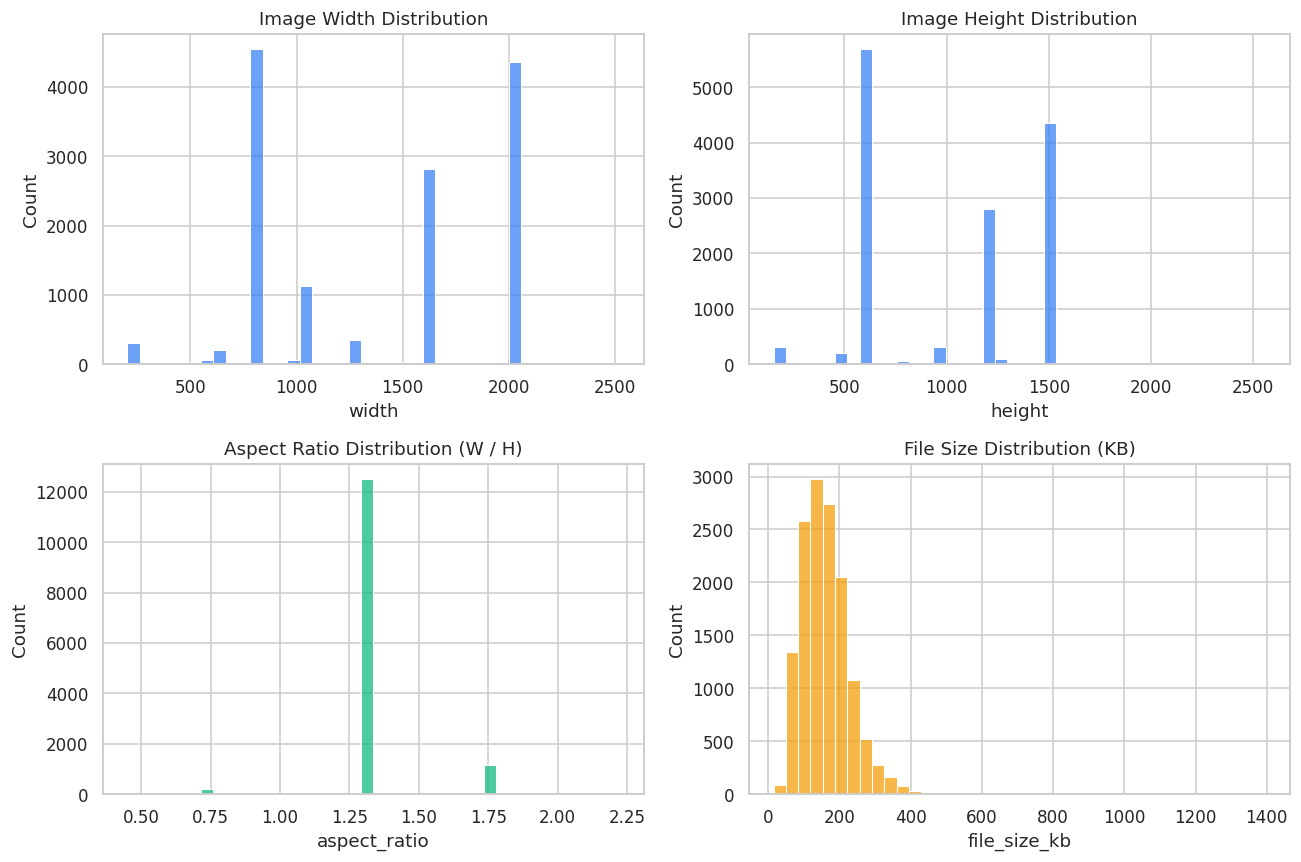

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(image_meta_df["width"], bins=40, ax=axes[0, 0], color="#3b82f6")
axes[0, 0].set_title("Image Width Distribution")

sns.histplot(image_meta_df["height"], bins=40, ax=axes[0, 1], color="#3b82f6")
axes[0, 1].set_title("Image Height Distribution")

sns.histplot(image_meta_df["aspect_ratio"], bins=40, ax=axes[1, 0], color="#10b981")
axes[1, 0].set_title("Aspect Ratio Distribution (W / H)")

sns.histplot(image_meta_df["file_size_kb"], bins=40, ax=axes[1, 1], color="#f59e0b")
axes[1, 1].set_title("File Size Distribution (KB)")

plt.tight_layout()
plt.show()


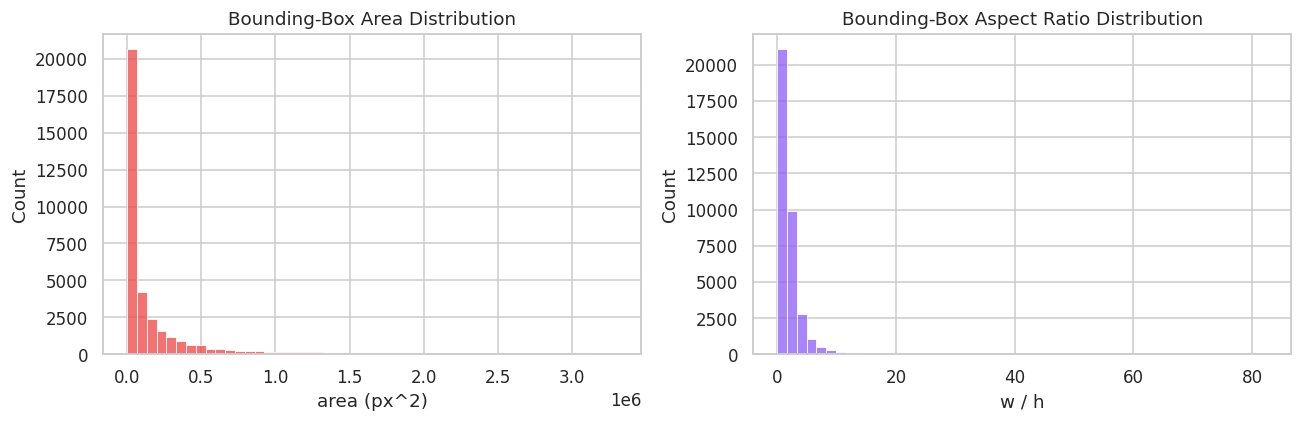

In [18]:
if not annotations_df.empty and "bbox" in annotations_df.columns:
    # COCO bbox format: [x, y, width, height]
    bbox_arr = np.array(annotations_df["bbox"].dropna().tolist())
    if bbox_arr.size:
        bbox_w, bbox_h = bbox_arr[:, 2], bbox_arr[:, 3]
        bbox_area = bbox_w * bbox_h

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        sns.histplot(bbox_area, bins=50, ax=axes[0], color="#ef4444")
        axes[0].set_title("Bounding-Box Area Distribution")
        axes[0].set_xlabel("area (px^2)")

        sns.histplot(bbox_w / bbox_h, bins=50, ax=axes[1], color="#8b5cf6")
        axes[1].set_title("Bounding-Box Aspect Ratio Distribution")
        axes[1].set_xlabel("w / h")
        plt.tight_layout()
        plt.show()
else:
    print("No bbox field found in annotations_df — skipping bbox-level distributions.")


## 7. Class Distribution

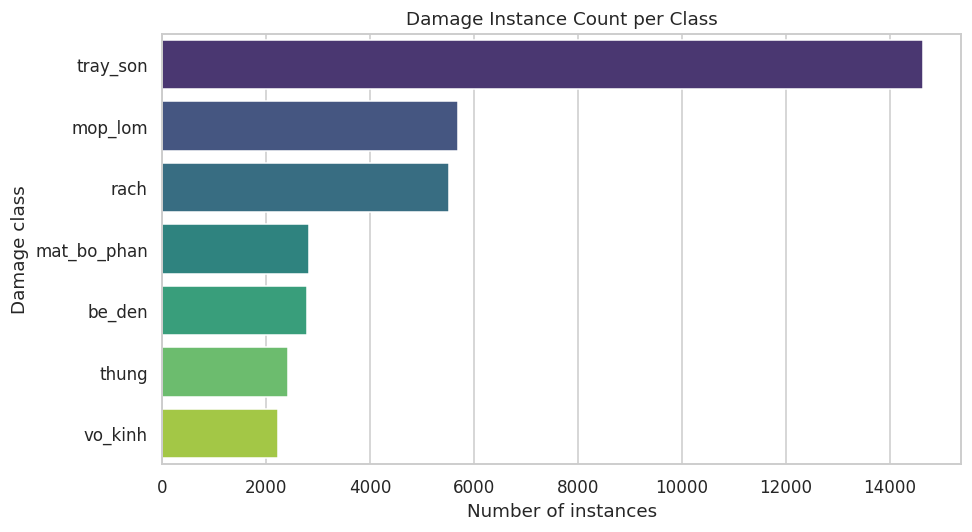

Class distribution (share of total instances):


,count
category_name,
tray_son,40.59 %
mop_lom,15.75 %
rach,15.27 %
mat_bo_phan,7.81 %
be_den,7.71 %
thung,6.72 %
vo_kinh,6.16 %



Class imbalance ratio (largest / smallest class): 6.59x


In [19]:
if not annotations_df.empty and "category_name" in annotations_df.columns:
    class_counts = annotations_df["category_name"].value_counts()

    plt.figure(figsize=(9, 5))
    sns.barplot(x=class_counts.values, y=class_counts.index, palette="viridis")
    plt.title("Damage Instance Count per Class")
    plt.xlabel("Number of instances")
    plt.ylabel("Damage class")
    plt.tight_layout()
    plt.show()

    print("Class distribution (share of total instances):")
    display((class_counts / class_counts.sum() * 100).round(2).astype(str) + " %")

    imbalance_ratio = class_counts.max() / class_counts.min()
    print(f"\nClass imbalance ratio (largest / smallest class): {imbalance_ratio:.2f}x")
else:
    print("category_name not available — check Section 2 parsing.")


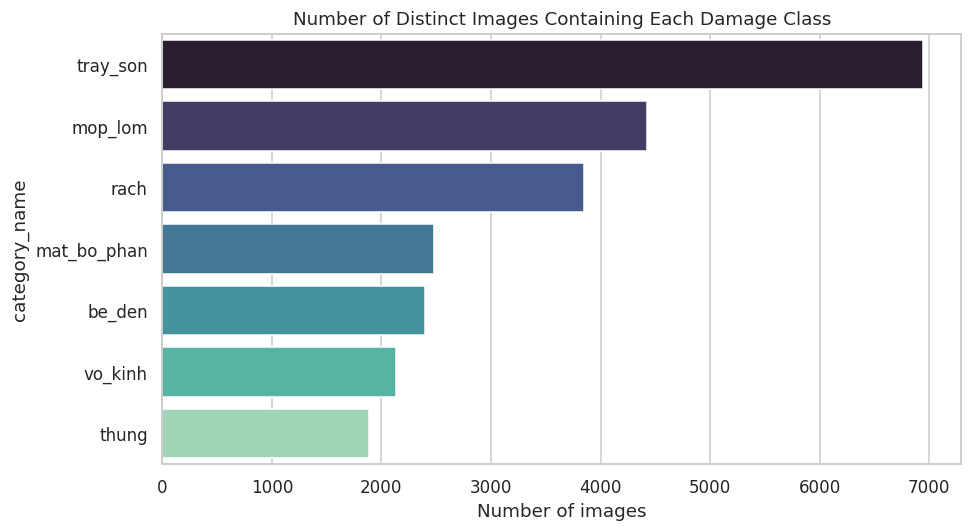

In [20]:
# Images per class (how many distinct images contain at least one instance of each class)
if not annotations_df.empty and "category_name" in annotations_df.columns:
    images_per_class = annotations_df.groupby("category_name")["image_id"].nunique().sort_values(ascending=False)
    plt.figure(figsize=(9, 5))
    sns.barplot(x=images_per_class.values, y=images_per_class.index, palette="mako")
    plt.title("Number of Distinct Images Containing Each Damage Class")
    plt.xlabel("Number of images")
    plt.tight_layout()
    plt.show()


## 8. Missing Value Analysis

In [21]:
# Null counts in the parsed DataFrames
print("Null counts — images_df:")
display(images_df.isnull().sum())
print("\nNull counts — annotations_df:")
display(annotations_df.isnull().sum())


Null counts — images_df:


,0
id,0
file_name,0
width,13945
height,13945



Null counts — annotations_df:


,0
id,0
image_id,0
category_id,0
bbox,0
area,0
category_name,0
file_name,0


In [22]:
# Images with zero annotated damage instances
if not images_df.empty and not annotations_df.empty:
    annotated_ids = set(annotations_df["image_id"].unique())
    all_ids = set(images_df["id"].unique())
    unannotated_ids = all_ids - annotated_ids
    print(f"Images with NO annotated instances: {len(unannotated_ids):,} "
          f"({len(unannotated_ids)/len(all_ids)*100:.1f}% of listed images)")


Images with NO annotated instances: 0 (0.0% of listed images)


In [23]:
# Annotation/image cross-check against files actually on disk
files_on_disk = {f.name for f in image_files}
if not images_df.empty:
    listed_files = set(images_df["file_name"].dropna())
    missing_on_disk = listed_files - files_on_disk
    extra_on_disk = files_on_disk - listed_files
    print(f"Annotated but missing from disk : {len(missing_on_disk):,}")
    print(f"On disk but not in annotations  : {len(extra_on_disk):,}")

Annotated but missing from disk : 0
On disk but not in annotations  : 0


In [24]:
# Corrupt / unreadable images found during Section 4's scan
if "corrupt" in image_meta_df.columns:
    n_corrupt = image_meta_df["corrupt"].fillna(False).sum()
    print(f"Corrupt / unreadable image files: {int(n_corrupt):,}")
    if n_corrupt:
        display(image_meta_df[image_meta_df["corrupt"] == True])
else:
    print("No corrupt images detected during scan.")

No corrupt images detected during scan.


## 9. Duplicate Analysis

In [25]:
def md5_of_file(path, chunk_size=8192):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()

In [26]:
# Hashing every image can be slow on the full dataset — cap it for a quick pass, raise if needed
HASH_SAMPLE_LIMIT = 5000
paths_to_hash = [Path(r["path"]) for _, r in image_meta_df.iterrows() if r.get("corrupt") != True][:HASH_SAMPLE_LIMIT]

hashes = defaultdict(list)
for p in paths_to_hash:
    hashes[md5_of_file(p)].append(p.name)

dupe_groups = {h: names for h, names in hashes.items() if len(names) > 1}
n_dupe_files = sum(len(v) for v in dupe_groups.values())
print(f"Hashed {len(paths_to_hash):,} images")
print(f"Exact duplicate images found: {n_dupe_files:,} files across {len(dupe_groups):,} duplicate groups")

for h, names in list(dupe_groups.items())[:5]:
    print(" -", names)

Hashed 5,000 images
Exact duplicate images found: 6 files across 3 duplicate groups
 - ['1bb0a803012020_100955image987950.jpg', '03012020_100955image987950.jpg']
 - ['2f24d508ba35426b1b24.jpg', 'a12825074a3ab264eb2b.jpg']
 - ['07012020_094906image332045.jpg', 'aa744a07012020_094906image332045.jpg']


In [27]:
# Duplicate annotation rows (same image_id + category_id + bbox logged more than once)
if not annotations_df.empty and "bbox" in annotations_df.columns:
    dup_key = annotations_df.apply(
        lambda r: (r["image_id"], r["category_id"], tuple(r["bbox"]) if isinstance(r["bbox"], list) else r["bbox"]),
        axis=1,
    )
    n_dup_annotations = dup_key.duplicated().sum()
    print(f"Duplicate annotation rows (identical image/category/bbox): {n_dup_annotations:,}")

Duplicate annotation rows (identical image/category/bbox): 0


## 10. Outlier Analysis

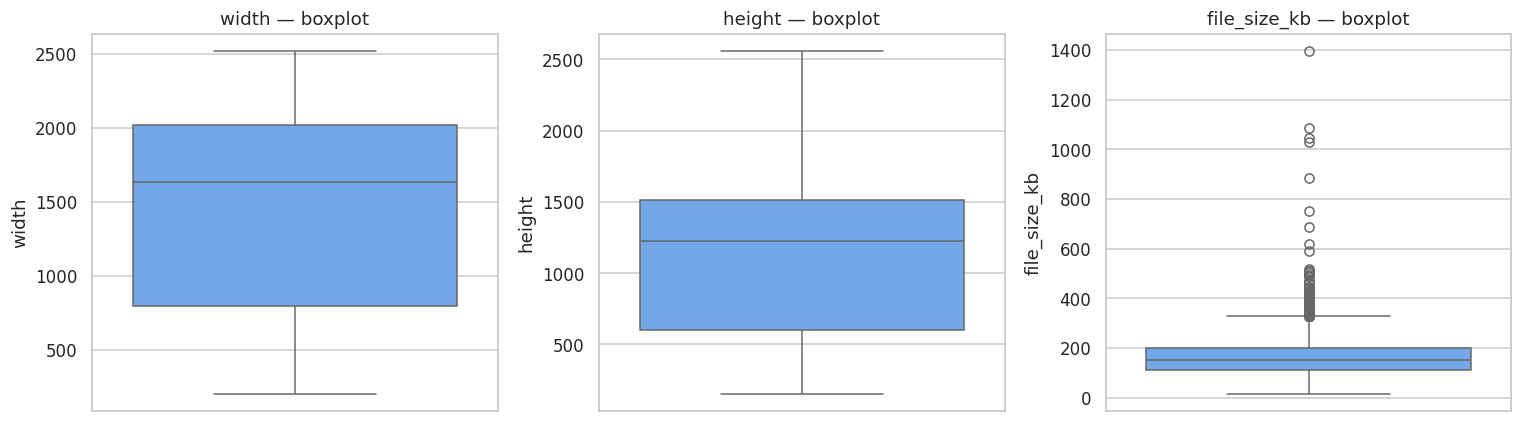

width: 0 outliers outside [-1024.0, 3840.0] (0.0%)
height: 0 outliers outside [-768.0, 2880.0] (0.0%)
file_size_kb: 288 outliers outside [-16.4, 327.7] (2.1%)


In [28]:
def iqr_outlier_mask(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return (series < lower) | (series > upper), lower, upper

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["width", "height", "file_size_kb"]):
    sns.boxplot(y=image_meta_df[col], ax=ax, color="#60a5fa")
    ax.set_title(f"{col} — boxplot")
plt.tight_layout()
plt.show()

for col in ["width", "height", "file_size_kb"]:
    mask, lo, hi = iqr_outlier_mask(image_meta_df[col])
    print(f"{col}: {mask.sum():,} outliers outside [{lo:.1f}, {hi:.1f}] "
          f"({mask.sum()/len(image_meta_df)*100:.1f}%)")

Bounding-box area: 4,503 outliers outside [-265080.0, 463808.0] (12.5%)


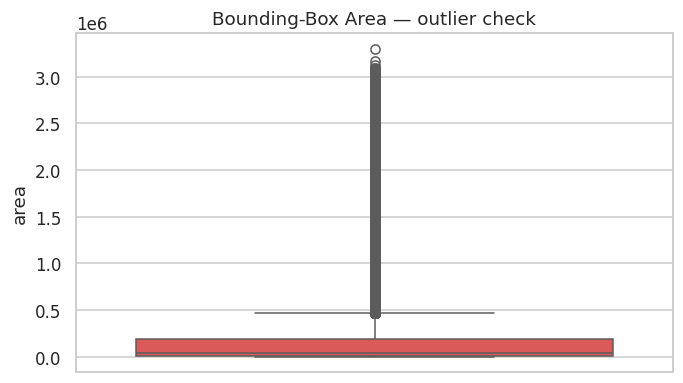


Instances-per-image: 816 outlier images outside [-2.0, 6.0]
Top 5 images by instance count:


,0
image_id,
505,20
8722,20
1423,19
9121,18
1832,16


In [29]:
if not annotations_df.empty and "area" in annotations_df.columns:
    area_series = annotations_df["area"].dropna()
    mask, lo, hi = iqr_outlier_mask(area_series)
    print(f"Bounding-box area: {mask.sum():,} outliers outside [{lo:.1f}, {hi:.1f}] "
          f"({mask.sum()/len(area_series)*100:.1f}%)")

    plt.figure(figsize=(7, 4))
    sns.boxplot(y=area_series, color="#ef4444")
    plt.title("Bounding-Box Area — outlier check")
    plt.show()

if not annotations_df.empty:
    inst_per_img = annotations_df.groupby("image_id").size()
    mask, lo, hi = iqr_outlier_mask(inst_per_img)
    print(f"\nInstances-per-image: {mask.sum():,} outlier images outside [{lo:.1f}, {hi:.1f}]")
    print("Top 5 images by instance count:")
    display(inst_per_img.sort_values(ascending=False).head())

## 11. Correlation Analysis

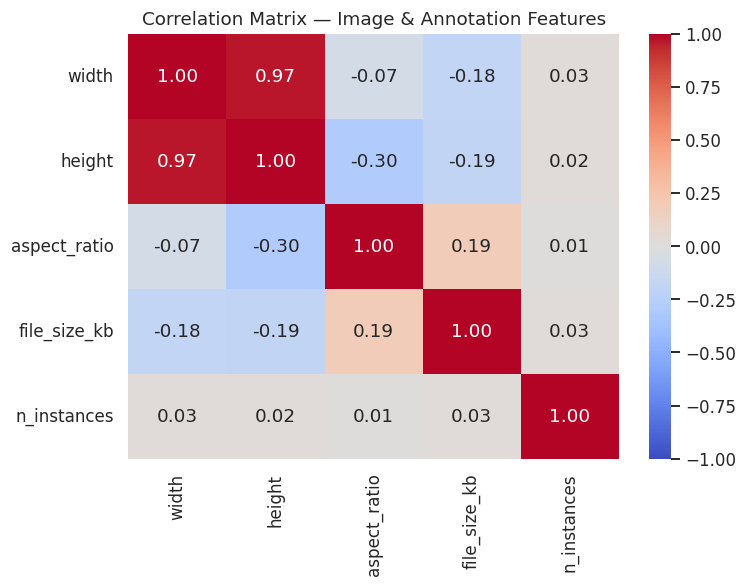

,width,height,aspect_ratio,file_size_kb,n_instances
width,1.000000,0.967406,-0.072634,-0.180792,0.027920
height,0.967406,1.000000,-0.295111,-0.192881,0.024349
aspect_ratio,-0.072634,-0.295111,1.000000,0.188288,0.011853
file_size_kb,-0.180792,-0.192881,0.188288,1.000000,0.025678
n_instances,0.027920,0.024349,0.011853,0.025678,1.000000


In [30]:
corr_df = image_meta_df[["width", "height", "aspect_ratio", "file_size_kb"]].copy()

if not annotations_df.empty:
    inst_per_img_map = annotations_df.groupby("image_id").size()
    # only meaningful if image_meta_df can be joined back to image_id — join on file_name if possible
    if "file_name" in images_df.columns:
        name_to_id = dict(zip(images_df["file_name"], images_df["id"]))
        corr_df["n_instances"] = image_meta_df["file_name"].map(name_to_id).map(inst_per_img_map)

corr_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation Matrix — Image & Annotation Features")
plt.tight_layout()
plt.show()

corr_matrix

## 12. Additional Visualizations

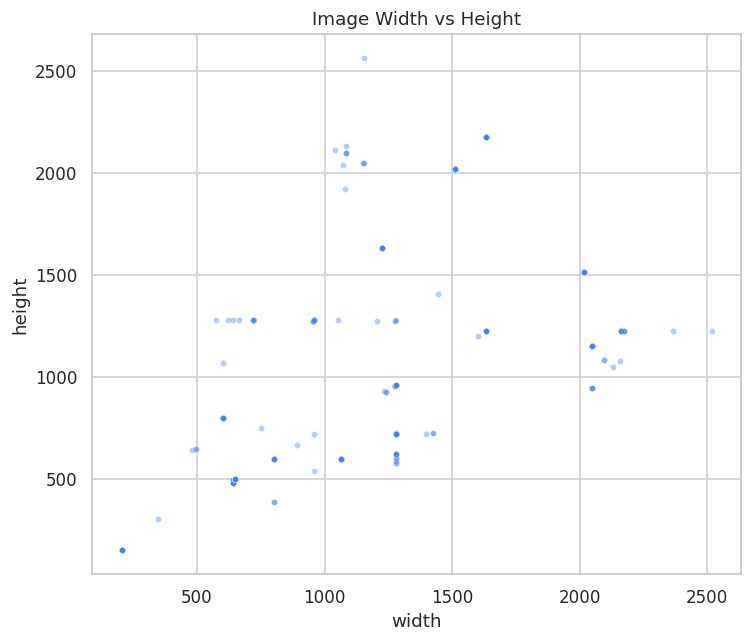

In [31]:
# Width vs Height scatter, colored by aspect-ratio bucket
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=image_meta_df, x="width", y="height",
    alpha=0.4, s=15, color="#3b82f6"
)
plt.title("Image Width vs Height")
plt.tight_layout()
plt.show()

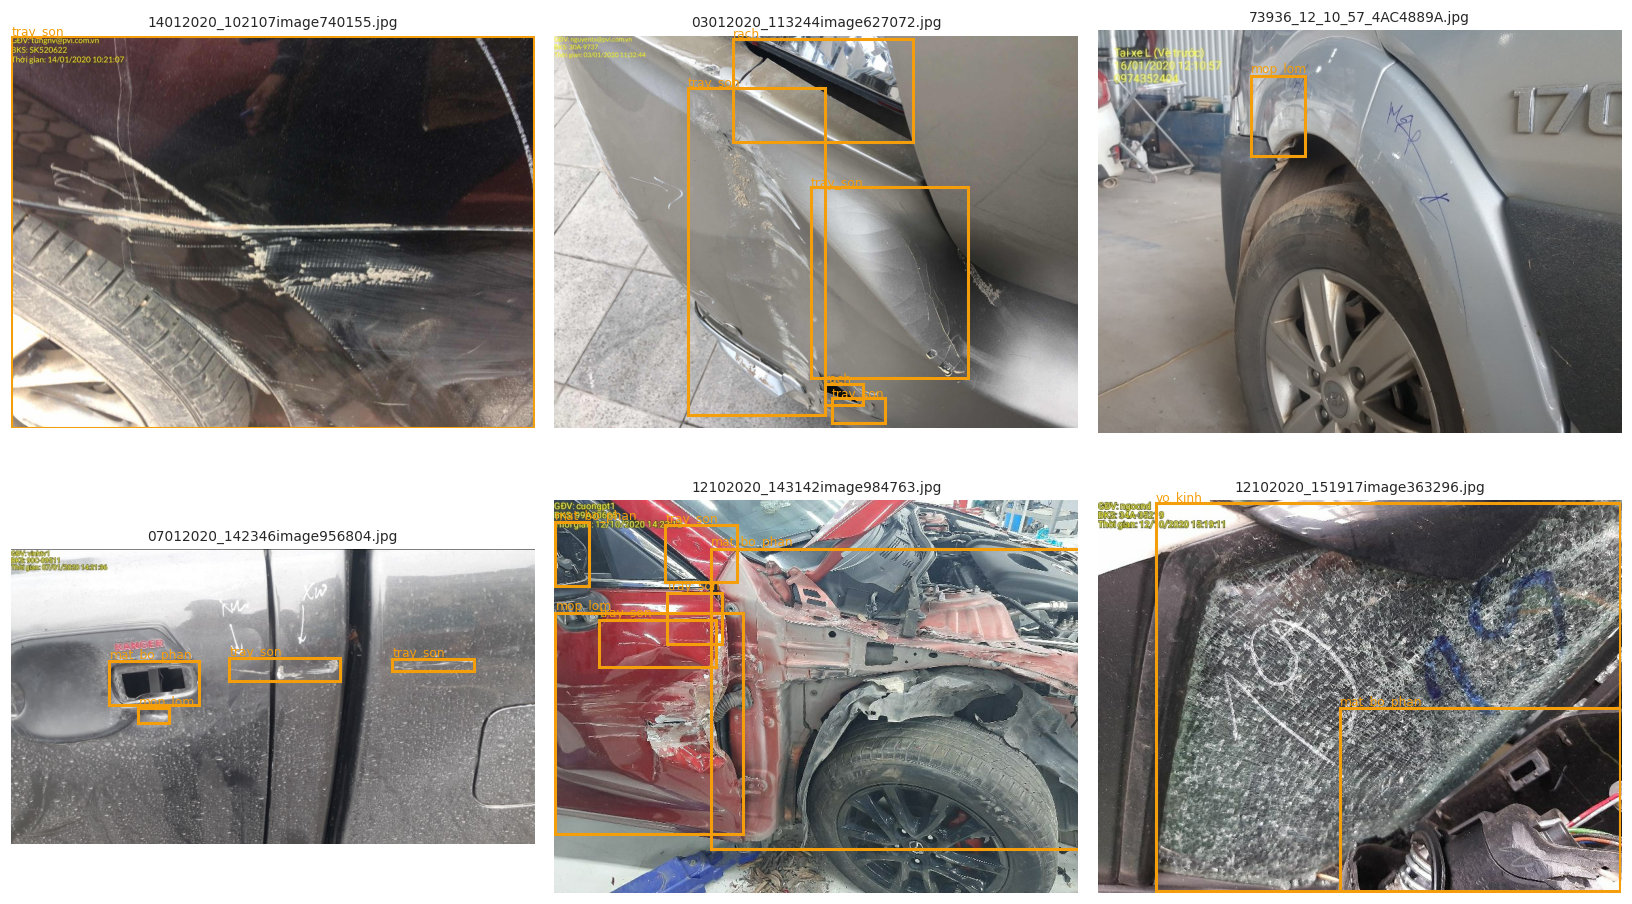

In [32]:
# Sample image grid with bounding boxes overlaid, one image per (available) class
import matplotlib.patches as patches

def show_sample_with_boxes(n_samples=6):
    if annotations_df.empty or "file_name" not in annotations_df.columns:
        print("No parsed annotations available to overlay — skipping.")
        return

    sample_ids = annotations_df["image_id"].drop_duplicates().sample(
        min(n_samples, annotations_df["image_id"].nunique()), random_state=42
    )

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.flatten()

    for ax, img_id in zip(axes, sample_ids):
        row = images_df[images_df["id"] == img_id]
        if row.empty:
            continue
        fname = row.iloc[0]["file_name"]
        match = [f for f in image_files if f.name == os.path.basename(fname)]
        if not match:
            continue
        img = Image.open(match[0])
        ax.imshow(img)
        boxes = annotations_df[annotations_df["image_id"] == img_id]
        for _, b in boxes.iterrows():
            if not isinstance(b.get("bbox"), list):
                continue
            x, y, w, h = b["bbox"]
            rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="#f59e0b", facecolor="none")
            ax.add_patch(rect)
            ax.text(x, max(y - 5, 0), str(b.get("category_name", "")), color="#f59e0b", fontsize=8)
        ax.set_title(fname, fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_sample_with_boxes()

## 12. Summary of Findings

- **Dataset size:** *(n images, n instances, n classes — from Section 4)*
- **Class balance:** *(imbalance ratio and which class dominates — from Section 7)*
- **Resolution consistency:** *(are images mostly uniform size or highly variable? — Section 6)*
- **Data quality issues found:** *(missing annotations, missing files, duplicates, corrupt
  images — Sections 8–9)*
- **Outliers:** *(any resolution or bbox-size outliers worth filtering before training —
  Section 10)*
- **Implications for the Damage/Severity Agent pipeline:** *(e.g. does class imbalance justify
  class-weighted loss or oversampling during YOLO fine-tuning? Do outlier bbox sizes suggest an
  anchor-size or image-resize adjustment?)*